In [1]:
import pandas as pd

df = pd.read_csv("heart (1).csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,country,clinical_index
0,28.0,1.0,2.0,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-3.920000
1,29.0,1.0,2.0,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,1,Hungary,-0.670000
2,29.0,1.0,2.0,140.0,NaN,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-1.947393
3,30.0,0.0,1.0,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0,Hungary,-1.160000
4,31.0,0.0,2.0,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-0.690000


In [2]:
df.shape

(920, 16)

In [ ]:
##The dataset contains 920 patients from four regions: Cleveland, Hungary, Switzerland, and VA Medical Center.
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,clinical_index
count,920.000000,920.000000,920.000000,861.000000,890.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000,865.000000
mean,53.510870,0.789130,3.250000,132.132404,199.130337,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.676375,5.087558,0.545652,0.077769
std,9.424685,0.408148,0.930969,19.066070,110.780810,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,0.935653,1.919075,0.498182,2.230653
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000,-6.020000
25%,47.000000,1.000000,3.000000,120.000000,175.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,-1.280000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000,0.310000
75%,60.000000,1.000000,4.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000,1.000000,1.560000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000,8.680000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             920 non-null    float64
 1   sex             920 non-null    float64
 2   cp              920 non-null    float64
 3   trestbps        861 non-null    float64
 4   chol            890 non-null    float64
 5   fbs             830 non-null    float64
 6   restecg         918 non-null    float64
 7   thalach         865 non-null    float64
 8   exang           865 non-null    float64
 9   oldpeak         858 non-null    float64
 10  slope           611 non-null    float64
 11  ca              309 non-null    float64
 12  thal            434 non-null    float64
 13  target          920 non-null    int64  
 14  country         920 non-null    object 
 15  clinical_index  865 non-null    float64
dtypes: float64(14), int64(1), object(1)
memory usage: 115.1+ KB


In [5]:
df.isna().sum()

age                 0
sex                 0
cp                  0
trestbps           59
chol               30
fbs                90
restecg             2
thalach            55
exang              55
oldpeak            62
slope             309
ca                611
thal              486
target              0
country             0
clinical_index     55
dtype: int64

In [6]:
df.groupby("country")["target"].mean()

country
Cleveland      0.448845
Hungary        0.380952
Switzerland    0.861789
VA             0.740000
Name: target, dtype: float64

In [10]:
df["country"].value_counts()

country
Cleveland      303
Hungary        294
VA             200
Switzerland    123
Name: count, dtype: int64

In [11]:
df["target"].value_counts()

target
1    502
0    418
Name: count, dtype: int64

In [7]:
df.groupby("country")[["ca", "thal", "slope"]].mean()

,ca,thal,slope
country,,,
Cleveland,0.672241,4.734219,1.600660
Hungary,0.000000,5.642857,1.894231
Switzerland,1.600000,5.788732,1.801887
VA,0.000000,6.294118,2.132653


The dataset contains 920 patient observations from four regions: Cleveland, Hungary, Switzerland, and VA. The target variable is binary and indicates whether a patient has heart disease. The dataset includes demographic and clinical variables such as age, sex, cholesterol, resting blood pressure, maximum heart rate, and chest pain type. The number of observations differs across regions, so the dataset is not perfectly balanced. Some variables already show fewer non-null values, which suggests that missing values need to be investigated in the next step.

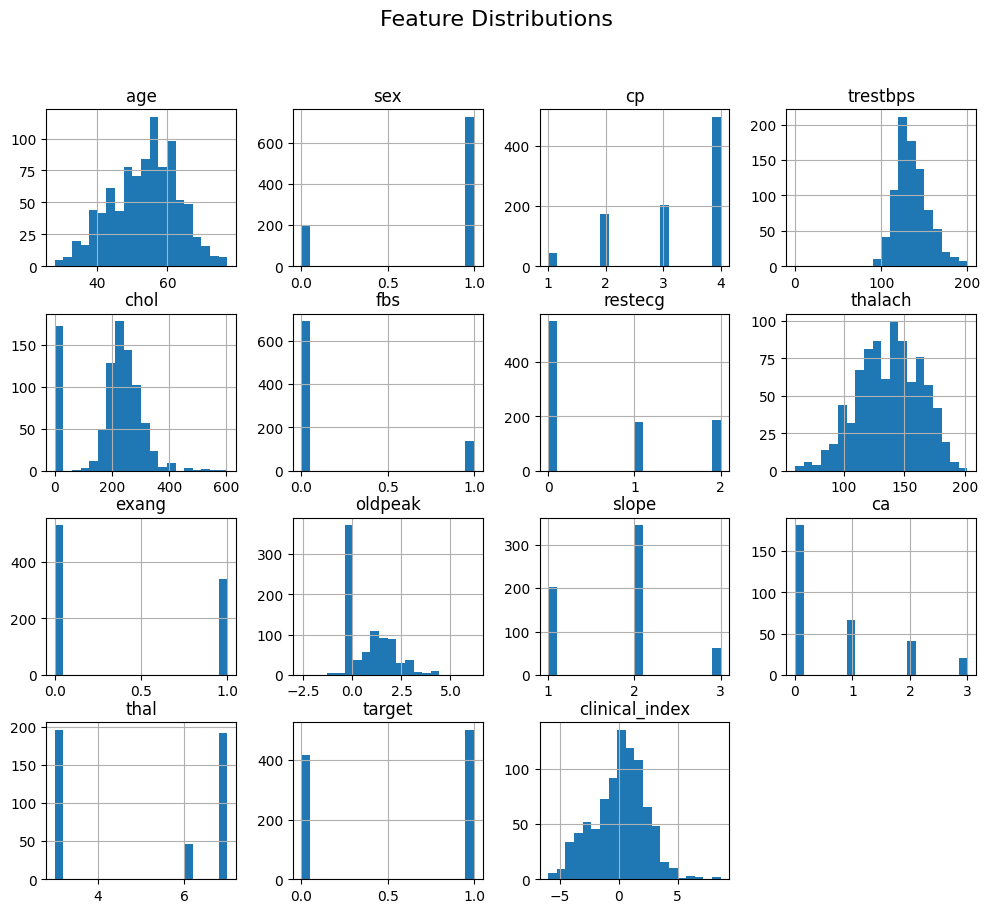

In [8]:
import matplotlib.pyplot as plt

df.hist(figsize = (12, 10), bins = 20)
plt.suptitle("Feature Distributions", fontsize = 16)
plt.show()

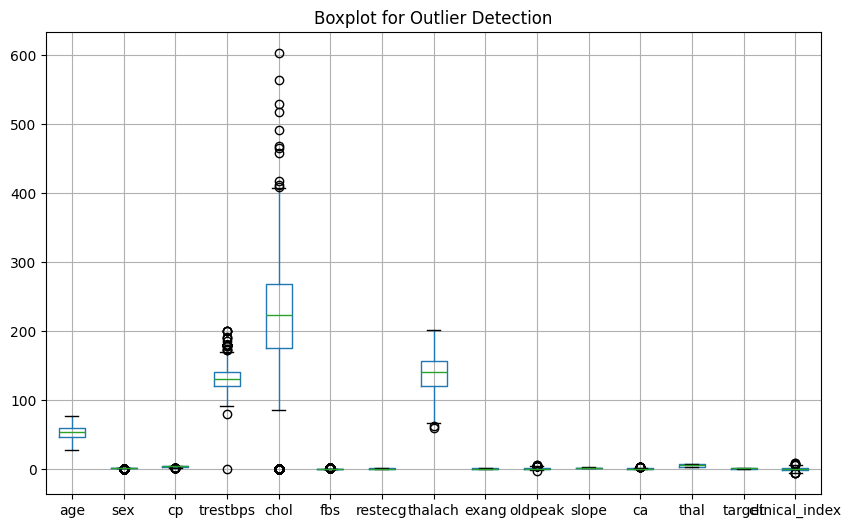

In [9]:
plt.figure(figsize = (10, 6))
df.boxplot()
plt.title("Boxplot for Outlier Detection")
plt.show()

Before modelling, we need to decide how to handle missing and suspicious values, because they are not equally distributed across regions.